# git log/history
<br>  

### References
- [Visualizing Code: Polyglot Notebooks Repository (YouTube)](https://youtu.be/ipOpToPS-PY?si=3doePt2cp-LgEUmt)
- [gitstractor (GitHub)](https://github.com/IntegerMan/gitstractor)
- [Neo4j Python Driver](https://neo4j.com/docs/api/python-driver/current)

In [1]:
import os
import numpy as np
import pandas as pd
#pd.options.mode.copy_on_write = True

In [2]:
from neo4j import GraphDatabase
from plotly import graph_objects as plotly_graph_objects
from plotly.express import colors as plotly_colors

In [3]:
# To be able to distinguish between command line execution and Jupyter notebook execution
# we need to check if the environment variable NBCONVERT is set.
# The command line execution is required to take care of setting NBCONVERT.

# Note: Even if it would be great to retain the interactivity of plotly Treemap plots (e.g. clicking into details)
#       for command line executed notebooks (via nbconvert),
#       it would require to execute the notebook twice: Once including interactivity and once for static Markdown and PDF.
#       Therefore, command line executed notebooks (nbconvert) will contain static graphics (here using svg).
def is_command_line_execution():
    return 'NBCONVERT' in os.environ

default_renderer = None

if is_command_line_execution():
    print("Command line execution (CLI mode): Yes")
    default_renderer = 'svg' # SVG is the default renderer for static (non interactive) pictures for command line execution
else:
    print("Command line execution (CLI mode): No")

Command line execution (CLI mode): Yes


In [4]:
# Please set the environment variable "NEO4J_INITIAL_PASSWORD" in your shell 
# before starting jupyter notebook to provide the password for the user "neo4j". 
# It is not recommended to hardcode the password into jupyter notebook for security reasons.

driver = GraphDatabase.driver(uri="bolt://localhost:7687", auth=("neo4j", os.environ.get("NEO4J_INITIAL_PASSWORD")))
driver.verify_connectivity()

In [5]:
def get_cypher_query_from_file(cypher_file_name : str):
    with open(cypher_file_name) as file:
        return ' '.join(file.readlines())


def query_cypher_to_data_frame(filename : str, limit: int = -1):
    """
    Execute the Cypher query of the given file and returns the result.
    filename : str : The name of the file containing the Cypher query
    limit : int : The optional limit of rows to optimize the query. Default = -1 = no limit
    """
    cypher_query = get_cypher_query_from_file(filename)
    if limit > 0:
        cypher_query = "{query}\nLIMIT {row_limit}".format(query = cypher_query, row_limit = limit)
    records, summary, keys = driver.execute_query(cypher_query)
    return pd.DataFrame([r.values() for r in records], columns=keys)


def query_first_non_empty_cypher_to_data_frame(*filenames : str, limit: int = -1):
    """
    Executes the Cypher queries of the given files and returns the first result that is not empty.
    If all given file names result in empty results, the last (empty) result will be returned.
    By additionally specifying "limit=" the "LIMIT" keyword will appended to query so that only the first results get returned.
    """    
    result=pd.DataFrame()
    for filename in filenames:
        result=query_cypher_to_data_frame(filename, limit)
        if not result.empty:
            return result
    return result

In [6]:
#The following cell uses the build-in %html "magic" to override the CSS style for tables to a much smaller size.
#This is especially needed for PDF export of tables with multiple columns.

In [7]:
%%html
<style>
/* CSS style for smaller dataframe tables. */
.dataframe th {
    font-size: 8px;
}
.dataframe td {
    font-size: 8px;
}
</style>

In [8]:
# Pandas DataFrame Display Configuration
pd.set_option('display.max_colwidth', 500)

## Git History - Directory Commit Statistics

In [9]:
# The first part provides functions that provide basic functionality for the following parts.

### Treemap Layout Functions and Constants

In [10]:
# Base settings for Plotly Treemap

plotly_main_layout_base_settings = dict(
    margin=dict(t=50, l=15, r=15, b=15),
)
plotly_treemap_layout_base_settings = dict(
    **plotly_main_layout_base_settings
)
plotly_bar_layout_base_settings = dict(
    **plotly_main_layout_base_settings
)
plotly_treemap_figure_show_settings = dict(
    renderer="svg" if is_command_line_execution() else None,
    width=1000,
    height=800
)

plotly_treemap_marker_base_style = dict(
    cornerradius=5, 
)

plotly_treemap_marker_base_colorscale = dict(
    **plotly_treemap_marker_base_style,
    colorscale='Hot_r', #  Hot_r, ice_r, Viridis_r, speed_r, haline_r, thermal_r, Plasma_r, solar_r, Electric_r, Blackbody_r, deep_r, Turbo_r, amp, Reds, Blackbody_r, RdGy_r, RdBu_r
)

In [11]:
def create_treemap_commit_statistics_settings(data_frame: pd.DataFrame):
    """
    Creates a Plotly Treemap with the given settings and data frame.
    data_frame : pd.DataFrame : The input data frame
    return :plotly_graph_objects.Treemap : The prepared Plotly Treemap
    """
    return plotly_graph_objects.Treemap(
        labels=data_frame['directoryName'],
        parents=data_frame['directoryParentPath'],
        ids=data_frame['directoryPath'],
        customdata=data_frame[['fileCount', 'mostFrequentFileExtension', 'commitCount', 'authorCount', 'mainAuthor', 'secondAuthor','lastCommitDate', 'daysSinceLastCommit', 'lastCreationDate', 'daysSinceLastCreation', 'lastModificationDate', 'daysSinceLastModification', 'directoryPath']],
        hovertemplate='<b>%{label}</b><br>Files: %{customdata[0]} (%{customdata[1]})<br>Commits: %{customdata[2]}<br>Authors: %{customdata[4]},  %{customdata[5]},.. (%{customdata[3]})<br>Last Commit: %{customdata[6]} (%{customdata[7]} days ago)<br>Last Created: %{customdata[8]} (%{customdata[9]} days ago)<br>Last Modified: %{customdata[10]} (%{customdata[11]} days ago)<br>Path: %{customdata[12]}',
        maxdepth=-1,
        root_color="lightgrey",
        marker=dict(**plotly_treemap_marker_base_style),
    )

In [12]:
def create_rank_colorbar_for_graph_objects_treemap_marker(data_frame: pd.DataFrame, name_column: str, rank_column: str):
    """
    Creates a plotly graph_objects.Treemap marker object for a colorbar representing ranked names.
    data_frame : pd.DataFrame : The DataFrame that contains the name and the count column
    name_column : str : The name of the column containing the ranking 
    rank_column : str : The name of the column containing the ranking 
    return : plotly_graph_objects.treemap.Marker : The created Marker object
    """
    # The rank is inverted so that the first rank is shown on the top of the colorbar.
    inverse_ranked = data_frame[rank_column].max() + 1 - data_frame[rank_column]

    return dict(
        cornerradius=5, 
        colors=inverse_ranked,
        colorscale=plotly_colors.qualitative.G10, #favorites: plotly_colors.qualitative.G10, Blackbody, ice, haline, hot
        colorbar=dict(
            title="Rank",
            tickmode="array",
            ticktext=data_frame[name_column],
            tickvals=inverse_ranked,
            tickfont_size=10
        ),
    )

### Visualization Data Preparation Functions

In [13]:
def add_quantile_limited_column(input_data_frame : pd.DataFrame, column_name : str, quantile : float = 0.95) -> pd.DataFrame:
    """
    Limits the values of the given column in the input data frame to the given quantile.
    The values are not filtered out but set to the limited (integer quantile value).
    input_data_frame : pd.DataFrame : The input data frame
    column_name : str : The name of the column to limit
    quantile : float : The quantile to limit the values to (default: 0.95)
    return : pd.DataFrame : The modified dataframe with the added column (column_name + '_limited')
    """
    data_frame=input_data_frame.copy()
    column_values = data_frame[column_name]
    column_limit = column_values.quantile(quantile)
    data_frame[column_name + '_limited'] = np.where(column_values > column_limit, column_limit, column_values)
    return data_frame

In [14]:
def add_rank_column(input_data_frame : pd.DataFrame, column_name : str) -> pd.DataFrame:
    """
    Adds a rank column ("dense" mode) to the input data frame based on the given column name.
    input_data_frame : pd.DataFrame : The input data frame
    column_name : str : The name of the column to rank
    return : pd.DataFrame : The modified dataframe with the added rank column
    """
    data_frame=input_data_frame.copy()
    data_frame[column_name + '_rank'] = data_frame[column_name].rank(ascending=True, method='dense')
    return data_frame

### File Data Preparation Functions

In [15]:
def get_last_entry(values: pd.Series):
    """
    Get the last element of an array and converts therefore an array to a single element
    Meant to be used as an aggregation function for dataframe grouping.
    values : Series : The pandas Series of values
    return : any : The last entry
    """
    return values[-1]


def add_file_extension_column(input_dataframe: pd.DataFrame, file_path_column: str, file_extension_column: str = 'fileExtension'):
    """
    Adds a fileExtension column to the input DataFrame based on the file path column.
    input_dataframe : pd.DataFrame : The input DataFrame
    file_path_column : str : The name of the file path column
    file_extension_column : str : The name of the file extension column to be added
    return : pd.DataFrame : The DataFrame with added directory column
    """
    if file_extension_column in input_dataframe.columns:
        return input_dataframe # Column already exists
    
    # What is the correct extension in the following cases?
    #  - /main/resources/META-INF/services/org.axonframework.messaging.annotation.HandlerEnhancerDefinition
    #  - MyReactComponent.test.tsx
    # Currently, it would be
    #  - HandlerEnhancerDefinition
    #  - tsx
    # which is not perfect but good enough to start with.#
    
    file_path_column_position = input_dataframe.columns.get_loc(file_path_column)
    file_extensions=input_dataframe[file_path_column].str.split('/').map(get_last_entry)
    file_extensions=file_extensions.str.split('.').map(get_last_entry)
    input_dataframe.insert(file_path_column_position + 1, file_extension_column, file_extensions)
    return input_dataframe

def remove_last_file_path_element(file_path_elements: list) -> list:
    """
    Removes the last element of the file path so that only the directory names retain.
    file_path_elements : list : The list of levels to remove
    return : list : The list of the directories
    """
    return file_path_elements[:-1] if len(file_path_elements) > 1 else ['']

def convert_path_elements_to_directories(file_path_elements: list) -> list:
    """
    Converts the file path elements into directories.
    file_path_elements : list : The list of levels to convert
    return : list : The list of directories
    """
    directories = remove_last_file_path_element(file_path_elements)
    return ['/'.join(directories[:i+1]) for i in range(len(directories))]

def add_directory_column(input_dataframe: pd.DataFrame, file_path_column: str, directory_column: str = 'directoryPath'):
    """
    Adds a directory column to the input DataFrame based on the file path column.
    input_dataframe : pd.DataFrame : The input DataFrame
    file_path_column : str : The name of the file path column
    directory_column : str : The name of the directory column to be added
    return : pd.DataFrame : The DataFrame with added directory column
    """
    if directory_column in input_dataframe.columns:
        return input_dataframe # Column already exists
    
    input_dataframe.insert(0, directory_column, input_dataframe[file_path_column].str.split('/').apply(convert_path_elements_to_directories))
    input_dataframe = input_dataframe.explode(directory_column)
    return input_dataframe

def add_directory_name_column(input_dataframe: pd.DataFrame, directory_column: str = 'directoryPath', directory_name_column: str = 'directoryName'):
    """
    Adds a directory name column to the input DataFrame based on the directory column.
    input_dataframe : pd.DataFrame : The input DataFrame
    directory_column : str : The name of the directory column
    directory_name_column : str : The name of the directory name column to be added
    return : pd.DataFrame : The DataFrame with added directory name column
    """
    if directory_name_column in input_dataframe.columns:
        return input_dataframe # Column already exists
    
    splitted_directories = input_dataframe[directory_column].str.rsplit('/', n=1)
    input_dataframe.insert(1, directory_name_column, splitted_directories.apply(lambda x: (x[-1])))
    return input_dataframe

def add_parent_directory_column(input_dataframe: pd.DataFrame, directory_column: str = 'directoryPath', directory_parent_column: str = 'directoryParentPath'):
    """
    Adds a directory parent column to the input DataFrame based on the directory column.
    input_dataframe : pd.DataFrame : The input DataFrame
    directory_column : str : The name of the directory column
    directory_parent_column : str : The name of the directory parent column to be added
    return : pd.DataFrame : The DataFrame with added directory parent column
    """
    if directory_parent_column in input_dataframe.columns:
        return input_dataframe # Column already exists
    
    # Remove last path element from directory_column to get the directory_parent_column
    splitted_directories = input_dataframe[directory_column].str.rsplit('/', n=1)
    input_dataframe.insert(1, directory_parent_column, splitted_directories.apply(lambda x: (x[0])))
    
    # Clear parent (set to empty string) when it equal to the directory
    input_dataframe.loc[input_dataframe[directory_parent_column] == input_dataframe[directory_column], directory_parent_column] = ''
    return input_dataframe


def collect_as_array(values: pd.Series):
    """
    Just collect all values (no operation, "noop")
    Meant to be used as an aggregation function for dataframe grouping.
    values : Series : The pandas Series of values
    return : any : The second entry
    """
    return np.asanyarray(values.to_list())

def second_entry(values: pd.Series):
    """
    Returns the second entry of a list of values.
    Meant to be used as an aggregation function for dataframe grouping.
    values : Series : The pandas Series of values
    return : any : The second entry
    """
    return values.iloc[1] if len(values) > 1 else None

def get_file_count_from_aggregated_file_paths(values: pd.Series):
    """
    Return the file count from an array of array of file paths.
    Meant to be used as an aggregation function for dataframe grouping.
    values : Series : The pandas Series of values
    return : int : The number of files
    """
    return len(np.unique(np.concatenate(values.to_list())))


def get_most_frequent_entry(input_values: pd.Series):
    """
    Flattens the array of arrays and return the most frequent entry .
    Meant to be used as an aggregation function for dataframe grouping.
    input_values : Series : The pandas Series of values
    return : str : The most frequent entry
    """
    # flatten the array of arrays 
    values = np.concatenate(input_values.to_list())
    # find frequency of each value
    values, counts = np.unique(values, return_counts=True)
    #display all values with highest frequencies
    return values[counts.argmax()]

### File Data Preparation 

In [16]:
git_files_with_commit_statistics = query_cypher_to_data_frame("../cypher/GitLog/List_git_files_with_commit_statistics_by_author.cypher")

# Get all authors, their commit count and based on it their rank in a separate dataframe.
# This will then be needed to visualize the (main) author for each directory.
git_file_authors=git_files_with_commit_statistics[['author', 'commitCount']].groupby('author').aggregate(
    authorCommitCount=pd.NamedAgg(column="commitCount", aggfunc="sum"),
    ).sort_values(by='authorCommitCount', ascending=False).reset_index()
git_file_authors['authorCommitCountRank'] = git_file_authors['authorCommitCount'].rank(ascending=False, method='dense').astype(int)

# Debug
# display(git_file_authors)

# Debug
# display("1. query result ---------------------")
# display(git_files_with_commit_statistics)

# Add new column 'fileExtension' for every 'filePath'
git_files_with_commit_statistics = add_file_extension_column(git_files_with_commit_statistics, 'filePath', 'fileExtension')

# Create a separate dataframe with all unique extensions, the number of their occurrences and the rank derived from it.
git_file_extensions=git_files_with_commit_statistics['fileExtension'].value_counts().rename_axis('fileExtension').reset_index(name='fileExtensionCount')
git_file_extensions['fileExtensionCountRank'] = git_file_extensions['fileExtensionCount'].rank(ascending=False, method='dense').astype(int)

# Debug
# display(git_file_extensions)

# Add multiple rows for each file path containing all its directories paths in the new column 'directoryPath'
git_files_with_commit_statistics = add_directory_column(git_files_with_commit_statistics, 'filePath', 'directoryPath')

# Debug
# display("2. added directoryPath and fileExtension --------------")
# display(git_files_with_commit_statistics)

# Define how common non-grouped columns will be aggregated.
# Hint: maxCommitSha might not seem very useful, but it actually helps by group similar directories in the final step
common_named_aggregation = dict(
    commitCount=pd.NamedAgg(column="commitCount", aggfunc="sum"),
    daysSinceLastCommit=pd.NamedAgg(column="daysSinceLastCommit", aggfunc="min"),
    daysSinceLastCreation=pd.NamedAgg(column="daysSinceLastCreation", aggfunc="min"),
    daysSinceLastModification=pd.NamedAgg(column="daysSinceLastModification", aggfunc="min"),
    lastCommitDate=pd.NamedAgg(column="lastCommitDate", aggfunc="max"),
    lastCreationDate=pd.NamedAgg(column="lastCreationDate", aggfunc="max"),
    lastModificationDate=pd.NamedAgg(column="lastModificationDate", aggfunc="max"),
    maxCommitSha=pd.NamedAgg(column="maxCommitSha", aggfunc="max"),
)

# Group the git files by their directory and author and count the number of files of each directory (across all levels).
git_files_with_commit_statistics = git_files_with_commit_statistics.groupby(['directoryPath', 'author']).aggregate(
    filePaths=pd.NamedAgg(column="filePath", aggfunc=np.unique),
    firstFile=pd.NamedAgg(column="filePath", aggfunc="first"),
    fileExtensions=pd.NamedAgg(column="fileExtension", aggfunc=collect_as_array),
    **common_named_aggregation
)

# Sort the grouped and aggregated entries by the name of the directory ascending and the number of commits descending.
# The author with the most commits will then be listed first for each directory.
git_files_with_commit_statistics = git_files_with_commit_statistics.sort_values(by=['directoryPath', 'commitCount'], ascending=[True, False])
git_files_with_commit_statistics = git_files_with_commit_statistics.reset_index()

# Debug
# display("3. grouped by 'directoryPath' and 'author' -----")
# display(git_files_with_commit_statistics)

# Group the entries again now only by their directory path to get the aggregated number of authors, the main author and the second author.
# Hint: firstFile (similar to maxCommitSha) might not seem very useful, but it also helps to group similar directories in the final step
git_files_with_commit_statistics = git_files_with_commit_statistics.groupby('directoryPath').aggregate(
    fileCount=pd.NamedAgg(column="filePaths", aggfunc=get_file_count_from_aggregated_file_paths),
    firstFile=pd.NamedAgg(column="firstFile", aggfunc="first"),
    mostFrequentFileExtension=pd.NamedAgg(column="fileExtensions", aggfunc=get_most_frequent_entry),
    authorCount=pd.NamedAgg(column="author", aggfunc="nunique"),
    mainAuthor=pd.NamedAgg(column="author", aggfunc="first"),
    secondAuthor=pd.NamedAgg(column="author", aggfunc=second_entry),
    **common_named_aggregation
)
git_files_with_commit_statistics = git_files_with_commit_statistics.reset_index()

# Debug
# display("4. grouped by 'directoryPath' ----------------------")
# display(git_files_with_commit_statistics)

# Add the name of the directory (last '/' separated element) and the parent directory path to the table.
git_files_with_commit_statistics = add_directory_name_column(git_files_with_commit_statistics, 'directoryPath', 'directoryName')
git_files_with_commit_statistics = add_parent_directory_column(git_files_with_commit_statistics, 'directoryPath', 'directoryParentPath')

# Debug
# display("5. added parent and name columns ------------")
# display(git_files_with_commit_statistics)

# Group finally by all columns except for the directory name, parent and path (first 3 columns) and pick the longest (max) directory path in case there are multiple.
all_column_names_except_for_the_directory_path = git_files_with_commit_statistics.columns.to_list()[3:]
git_files_with_commit_statistics = git_files_with_commit_statistics.groupby(all_column_names_except_for_the_directory_path).aggregate(
   directoryName=pd.NamedAgg(column="directoryName", aggfunc=lambda names: '/'.join(names)),
   directoryParentPath=pd.NamedAgg(column="directoryParentPath", aggfunc="first"),
   directoryPath=pd.NamedAgg(column="directoryPath", aggfunc="last"),
)
# Reorder the column positions so that the directory path is again the first column. 
all_column_names_with_the_directory_path_first = ['directoryPath', 'directoryParentPath', 'directoryName'] + all_column_names_except_for_the_directory_path
git_files_with_commit_statistics = git_files_with_commit_statistics.reset_index()[all_column_names_with_the_directory_path_first]

# Debug
# display("6. grouped by all except for directory path, name and parent columns (max) ----------------------")
# display(git_files_with_commit_statistics)

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.AggregationSkippedNull} {category: UNRECOGNIZED} {title: The query contains an aggregation function that skips null values.} {description: null value eliminated in set function.} {position: None} for query: "// List git files with commit statistics\n \n  MATCH (git_file:File&Git&!Repository)\n  WHERE git_file.deletedAt IS NULL // filter out deleted files\n   WITH percentileDisc(git_file.createdAtEpoch, 0.5)          AS medianCreatedAtEpoch\n       ,percentileDisc(git_file.lastModificationAtEpoch, 0.5) AS medianLastModificationAtEpoch\n       ,collect(git_file)                                     AS git_files\n UNWIND git_files AS git_file\n   WITH *\n       ,datetime.fromepochMillis(coalesce(git_file.createdAtEpoch, medianCreatedAtEpoch))                                            AS fileCreatedAtTimestamp\n       ,datetime.fromepochMillis(coalesce(git_file.lastModificationAtEpoch, git_f

### Data Preview

In [17]:
git_files_with_commit_statistics.describe()

,fileCount,authorCount,commitCount,daysSinceLastCommit,daysSinceLastCreation,daysSinceLastModification
count,291.000000,291.000000,291.000000,291.000000,291.000000,291.000000
mean,13.240550,7.728522,343.522337,420.237113,671.680412,599.786942
std,53.778125,7.038209,1446.295449,1068.709845,1241.224911,1252.384978
min,1.000000,2.000000,2.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,24.000000,2.000000,69.000000,15.000000
50%,3.000000,7.000000,74.000000,64.000000,265.000000,112.000000
75%,8.000000,8.000000,181.000000,234.000000,367.000000,276.000000
max,828.000000,70.000000,21397.000000,4775.000000,4863.000000,4774.000000


In [18]:
git_files_with_commit_statistics.head(30)

,directoryPath,directoryParentPath,directoryName,fileCount,firstFile,mostFrequentFileExtension,authorCount,mainAuthor,secondAuthor,commitCount,daysSinceLastCommit,daysSinceLastCreation,daysSinceLastModification,lastCommitDate,lastCreationDate,lastModificationDate,maxCommitSha
0,AxonFramework-4.11.1/.idea/copyright,AxonFramework-4.11.1/.idea,copyright,1,AxonFramework-4.11.1/.idea/copyright/Axon_Framework_copyright_template.xml,xml,2,Steven van Beelen,Allard Buijze,9,26,71,71,2025-02-24,2025-01-09,2025-01-09,fe926a4970bdf1e538e8e7fb8d147ffdc676e713
1,AxonFramework-4.11.1/.idea/inspectionProfiles,AxonFramework-4.11.1/.idea,inspectionProfiles,1,AxonFramework-4.11.1/.idea/inspectionProfiles/Project_Default.xml,xml,2,Steven van Beelen,Allard Buijze,9,26,71,71,2025-02-24,2025-01-09,2025-01-09,fe926a4970bdf1e538e8e7fb8d147ffdc676e713
2,AxonFramework-4.11.1/axon-5-module-structure-suggestion/messaging-core/src/test/java/org/axonframework/messaging,AxonFramework-4.11.1/axon-5-module-structure-suggestion/messaging-core/src,test/java/org/axonframework/messaging,1,AxonFramework-4.11.1/axon-5-module-structure-suggestion/messaging-core/src/test/java/org/axonframework/messaging/UnitOfWorkTest.java,java,2,Steven van Beelen,Mitchell Herrijgers,13,26,511,511,2025-02-24,2023-10-27,2023-10-27,ea5ee757f6536e2b4f6f5d0cac71a07b94c4c0c4
3,AxonFramework-4.11.1/axon-server-connector/src/main/java/org/axonframework/axonserver/connector/command,AxonFramework-4.11.1/axon-server-connector/src/main/java/org/axonframework/axonserver/connector,command,1,AxonFramework-4.11.1/axon-server-connector/src/main/java/org/axonframework/axonserver/connector/command/AxonServerConnector.java,java,3,Steven van Beelen,Allard Buijze,41,26,367,44,2025-02-24,2024-03-19,2025-02-05,fcedac961db62285c0c224c507284ef1746d5f35
4,AxonFramework-4.11.1/core/src/test/java/org/axonframework/commandhandling/disruptor,AxonFramework-4.11.1/core/src/test/java/org/axonframework,commandhandling/disruptor,1,AxonFramework-4.11.1/core/src/test/java/org/axonframework/commandhandling/disruptor/EventPublisherTest.java,java,2,Allard Buijze,Rene de Waele,2,3453,3475,3452,2015-10-08,2015-09-15,2015-10-08,30d68fd229c59f5aa8f45848de82c91967eebcba
5,AxonFramework-4.11.1/core/src/test/java/org/axonframework/contextsupport/spring,AxonFramework-4.11.1/core/src/test/java/org/axonframework,contextsupport/spring,1,AxonFramework-4.11.1/core/src/test/java/org/axonframework/contextsupport/spring/WiringTest.java,java,2,Sebastian Ganslandt,lburgazzoli,2,4218,4312,4312,2013-09-03,2013-05-31,2013-05-31,f17a45795111f567ca57f97c63a976c1a9a2cce0
6,AxonFramework-4.11.1/core/src/test/java/org/axonframework/eventhandling/scheduling/quartz,AxonFramework-4.11.1/core/src/test/java/org/axonframework,eventhandling/scheduling/quartz,1,AxonFramework-4.11.1/core/src/test/java/org/axonframework/eventhandling/scheduling/quartz/Quartz2EventSchedulerTest.java,java,14,Allard Buijze,smcvb,121,235,4658,4658,2024-07-30,2012-06-20,2012-06-20,fdd51aa788071375721c67bb30bf5709136e974a
7,AxonFramework-4.11.1/docs/_playbook/localLinks,AxonFramework-4.11.1/docs/_playbook,localLinks,1,AxonFramework-4.11.1/docs/_playbook/localLinks/axoniq-library-ui,axoniq-library-ui,7,Steven van Beelen,Allard Buijze,13,234,288,288,2024-07-31,2024-06-07,2024-06-07,fcf55fb4f72d050c0949cac6a1818df2cd53d608
8,AxonFramework-4.11.1/docs/_reference/modules/ROOT/attachments,AxonFramework-4.11.1/docs/_reference/modules/ROOT,attachments,1,AxonFramework-4.11.1/docs/_reference/modules/ROOT/attachments/axonframework_overview.gv,gv,8,Steven van Beelen,Milen Dyankov,22,234,276,276,2024-07-31,2024-06-19,2024-06-19,f851948ee70e6cc9742c7b1bde5941ed2655e28f
9,AxonFramework-4.11.1/docs/_reference/modules/ROOT/partials,AxonFramework-4.11.1/docs/_reference/modules/ROOT,partials,1,AxonFramework-4.11.1/docs/_reference/modules/ROOT/partials/nav.adoc,adoc,8,Steven van Beelen,Milen Dyankov,22,234,276,276,2024-07-31,2024-06-19,2024-06-19,f851948ee70e6cc9742c7b1bde5941ed2655e28f


### Number of files per directory

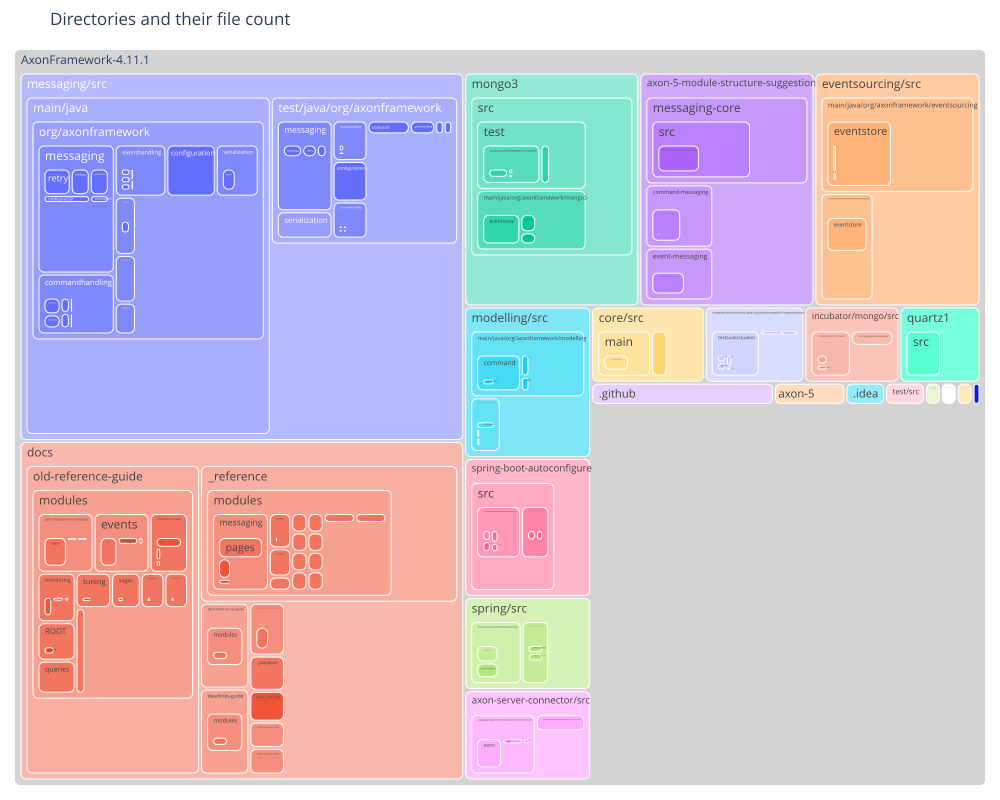

In [19]:
figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_files_with_commit_statistics),
    values = git_files_with_commit_statistics['fileCount'],
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Directories and their file count'
)
figure.show(**plotly_treemap_figure_show_settings)

### Most frequent file extension per directory

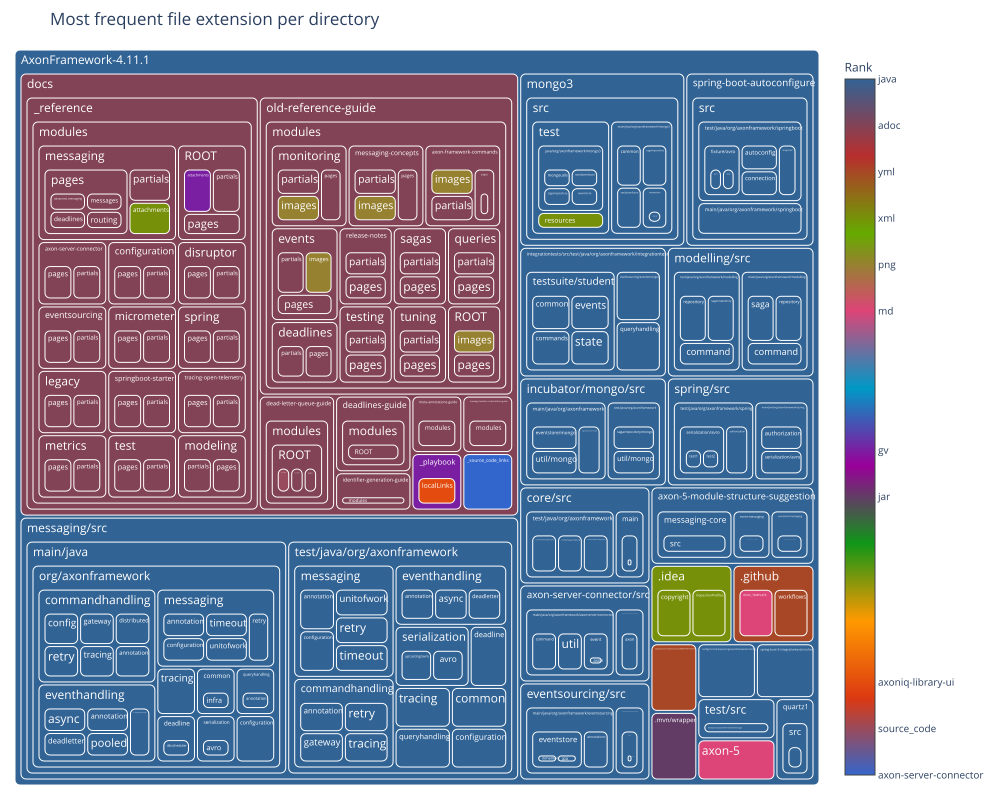

In [20]:
git_files_with_commit_statistics_and_file_extension_rank = pd.merge(
    git_files_with_commit_statistics, 
    git_file_extensions, 
    left_on='mostFrequentFileExtension', 
    right_on="fileExtension",
    how="left",
    validate="m:1"
)
figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_files_with_commit_statistics),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_files_with_commit_statistics['fileCount'],
    marker=create_rank_colorbar_for_graph_objects_treemap_marker(git_files_with_commit_statistics_and_file_extension_rank, 'fileExtension', 'fileExtensionCountRank')
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Most frequent file extension per directory'
)
figure.show(**plotly_treemap_figure_show_settings)

### Number of commits per directory

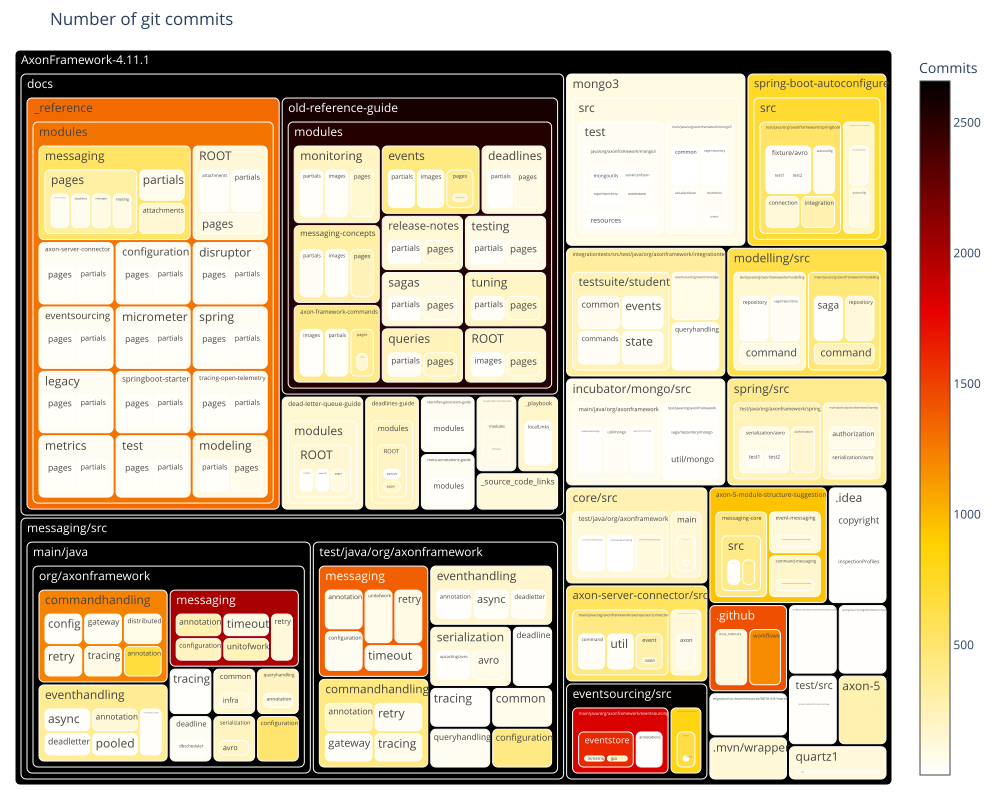

In [21]:
git_commit_count_per_directory = add_quantile_limited_column(git_files_with_commit_statistics, "commitCount", 0.98)

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_count_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_commit_count_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_count_per_directory['commitCount_limited'], 
        colorbar=dict(title="Commits"),
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Number of git commits',
)
figure.show(**plotly_treemap_figure_show_settings)

### Number of distinct authors per directory

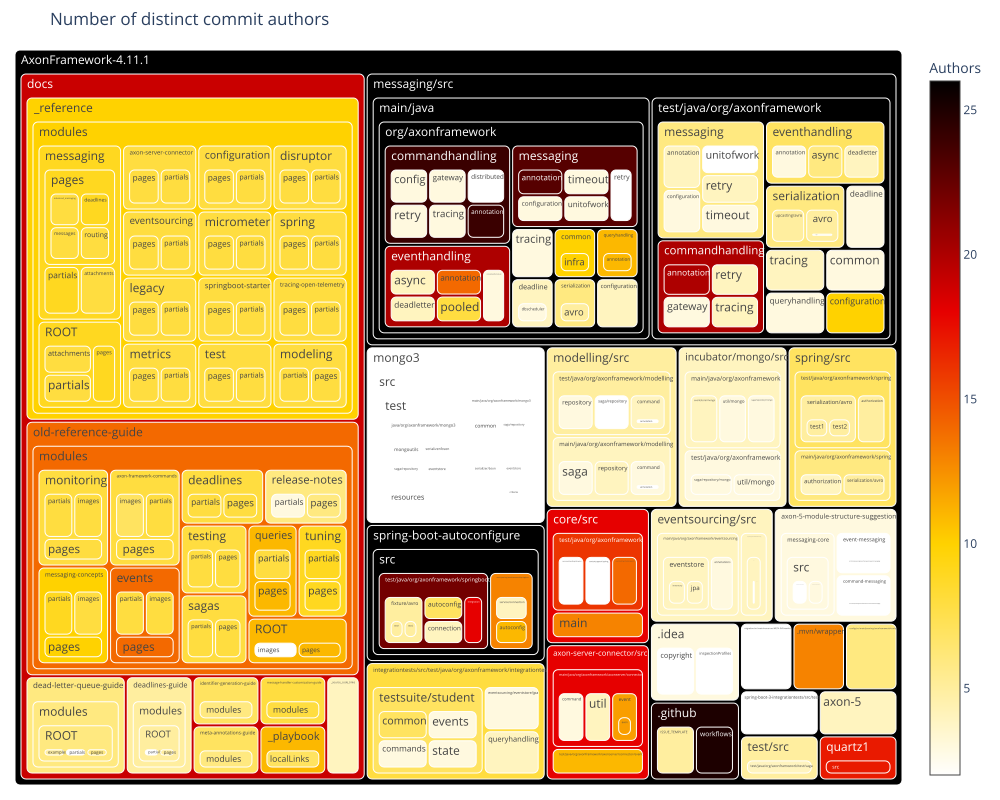

In [22]:
git_commit_authors_per_directory = add_quantile_limited_column(git_files_with_commit_statistics, "authorCount", 0.98)

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_authors_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_commit_authors_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_authors_per_directory['authorCount_limited'], 
        colorbar=dict(title="Authors"),
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Number of distinct commit authors',
)
figure.show(**plotly_treemap_figure_show_settings)

### Main author per directory

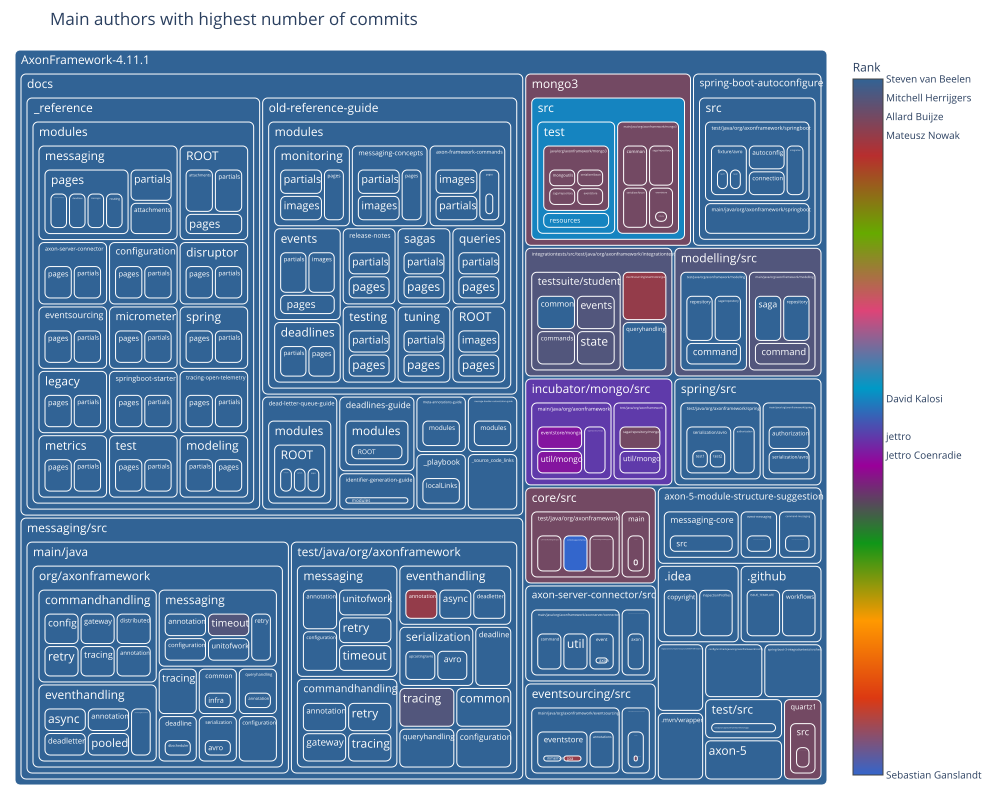

In [23]:
git_files_with_commit_statistics_and_main_author_rank = pd.merge(
    git_files_with_commit_statistics, 
    git_file_authors, 
    left_on='mainAuthor', 
    right_on="author",
    how="left",
    validate="m:1"
)
figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_files_with_commit_statistics),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_files_with_commit_statistics['fileCount'],
    marker=create_rank_colorbar_for_graph_objects_treemap_marker(git_files_with_commit_statistics_and_main_author_rank, 'mainAuthor', 'authorCommitCountRank')
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Main authors with highest number of commits'
)
figure.show(**plotly_treemap_figure_show_settings)

### Second author per directory

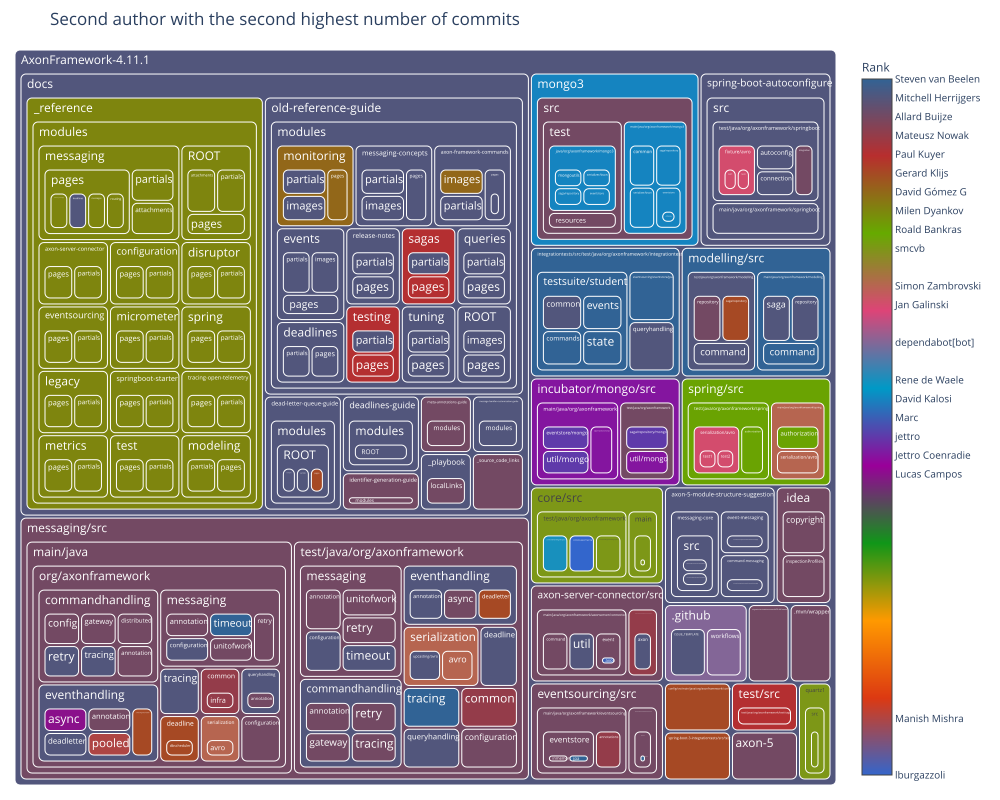

In [24]:
git_files_with_commit_statistics_and_second_author_rank = pd.merge(
    git_files_with_commit_statistics, 
    git_file_authors, 
    left_on='secondAuthor', 
    right_on="author",
    how="left",
    validate="m:1"
)

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_files_with_commit_statistics),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_files_with_commit_statistics['fileCount'],
    marker=create_rank_colorbar_for_graph_objects_treemap_marker(git_files_with_commit_statistics_and_second_author_rank, 'secondAuthor', 'authorCommitCountRank')
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Second author with the second highest number of commits'
)
figure.show(**plotly_treemap_figure_show_settings)

### Days since last commit per directory

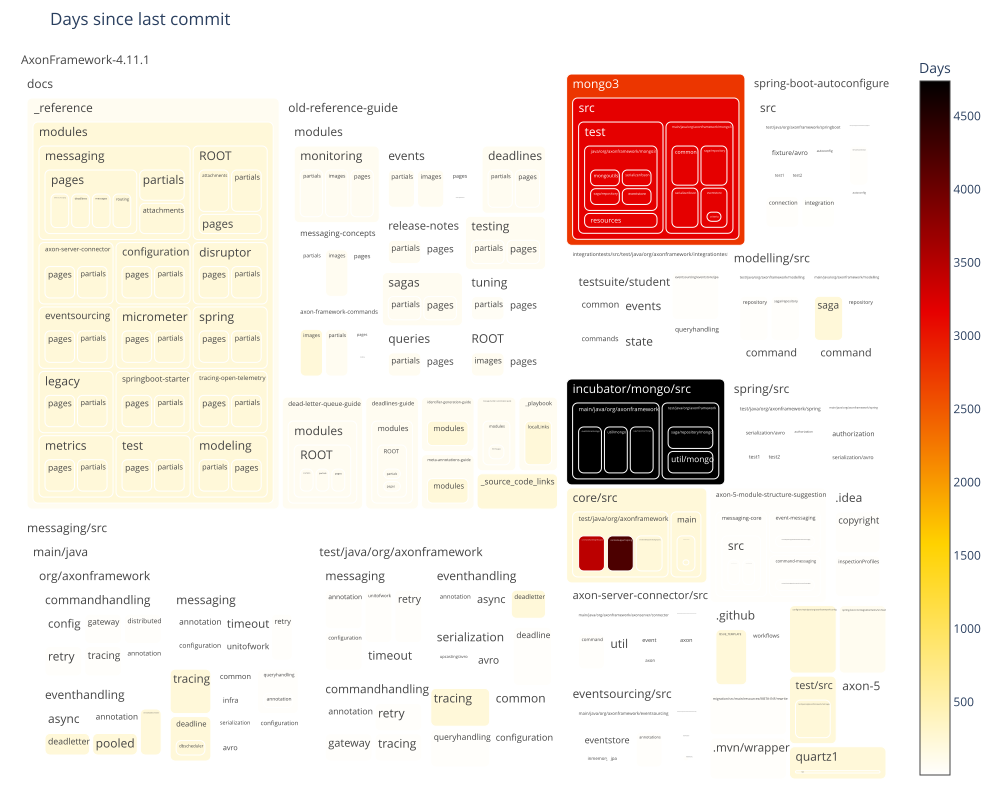

In [25]:
git_commit_days_since_last_commit_per_directory = add_quantile_limited_column(git_files_with_commit_statistics, "daysSinceLastCommit", 0.98)

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_days_since_last_commit_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    #values = git_commit_days_since_last_commit_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_days_since_last_commit_per_directory['daysSinceLastCommit_limited'], 
        colorbar=dict(title="Days"),
    ),
))

figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Days since last commit',
)
figure.show(**plotly_treemap_figure_show_settings)

### Days since last commit per directory (ranked)

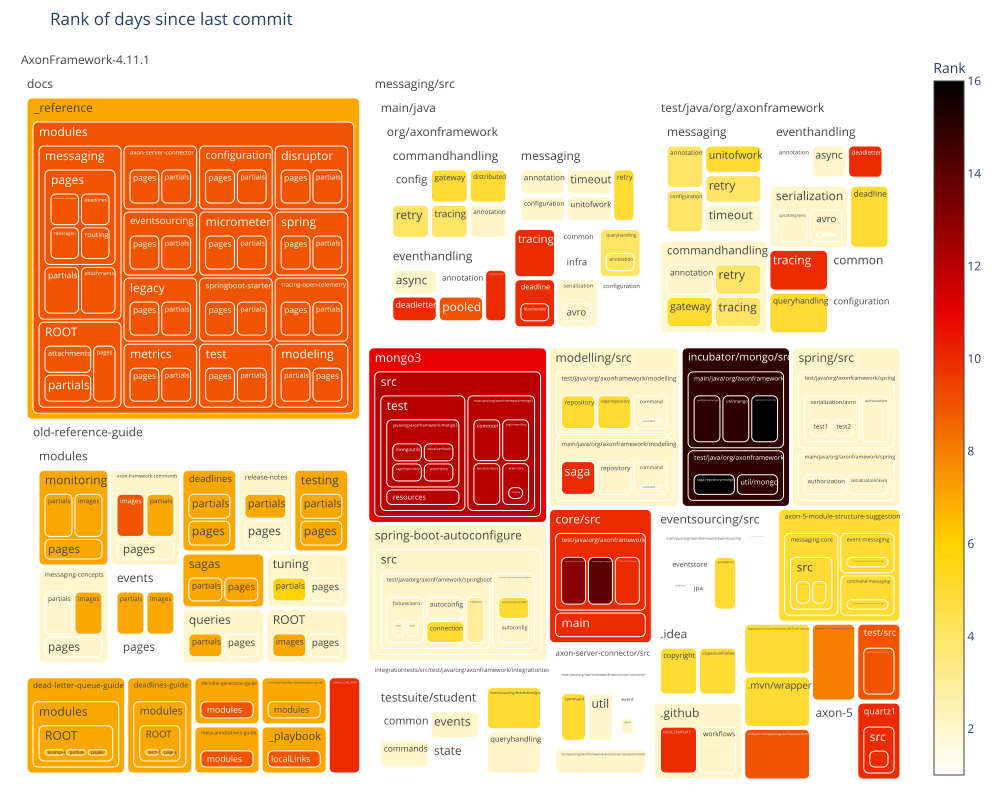

In [26]:
git_commit_days_since_last_commit_per_directory = add_rank_column(git_files_with_commit_statistics, "daysSinceLastCommit")

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_days_since_last_commit_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_commit_days_since_last_commit_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_days_since_last_commit_per_directory['daysSinceLastCommit_rank'], 
        colorbar=dict(title="Rank"),
    ),
))

figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Rank of days since last commit',
)
figure.show(**plotly_treemap_figure_show_settings)

### Days since last file creation per directory

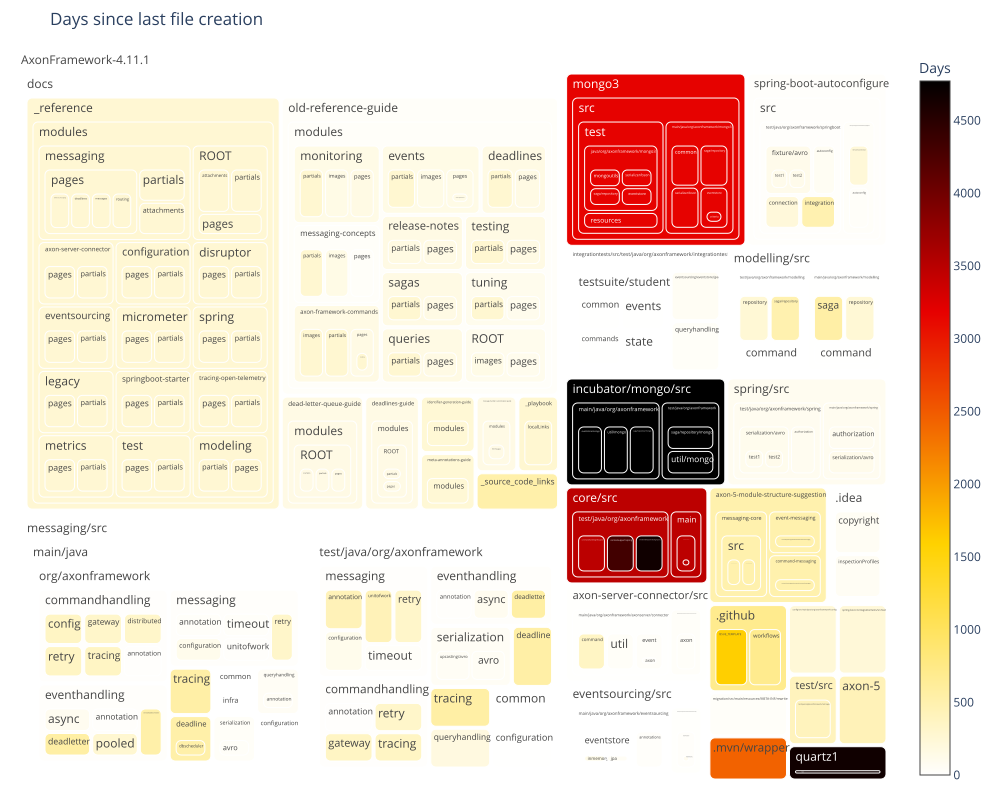

In [27]:
git_commit_days_since_last_file_creation_per_directory = add_quantile_limited_column(git_files_with_commit_statistics, "daysSinceLastCreation", 0.98)

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_days_since_last_file_creation_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_commit_days_since_last_file_creation_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_days_since_last_file_creation_per_directory['daysSinceLastCreation_limited'], 
        colorbar=dict(title="Days"),
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Days since last file creation',
)
figure.show(**plotly_treemap_figure_show_settings)

### Days since last file creation per directory (ranked)

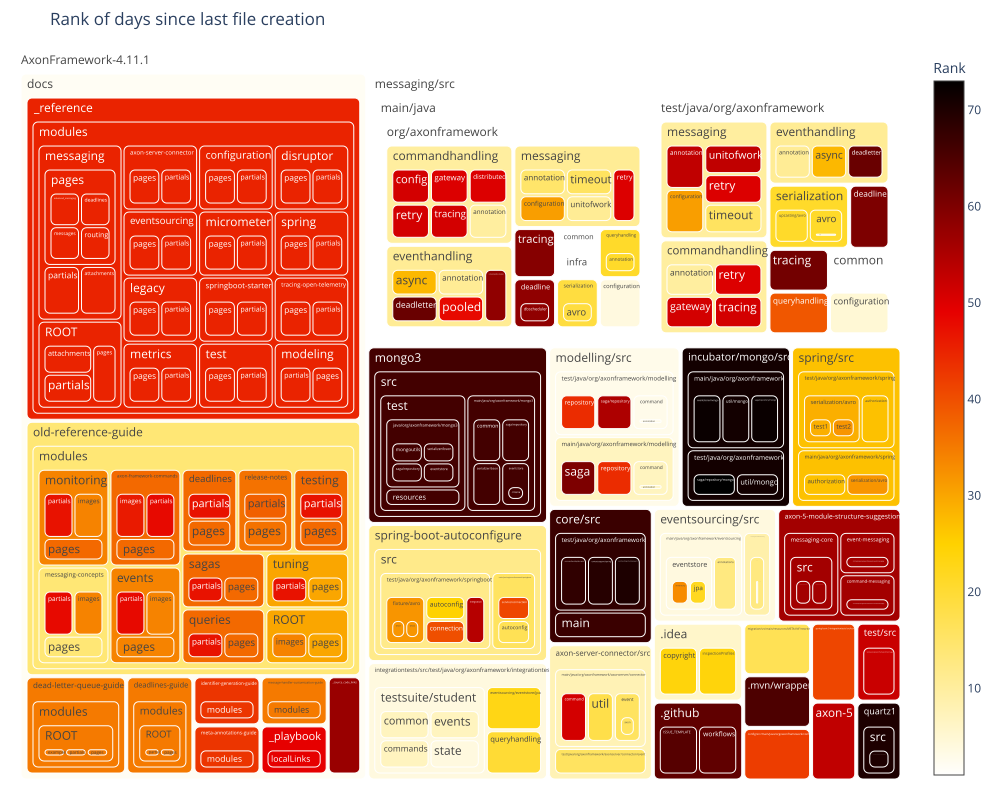

In [28]:
git_commit_days_since_last_file_creation_per_directory = add_rank_column(git_files_with_commit_statistics, "daysSinceLastCreation")

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_days_since_last_file_creation_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_commit_days_since_last_file_creation_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_days_since_last_file_creation_per_directory['daysSinceLastCreation_rank'], 
        colorbar=dict(title="Rank"),
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Rank of days since last file creation',
)
figure.show(**plotly_treemap_figure_show_settings)

### Days since last file modification per directory

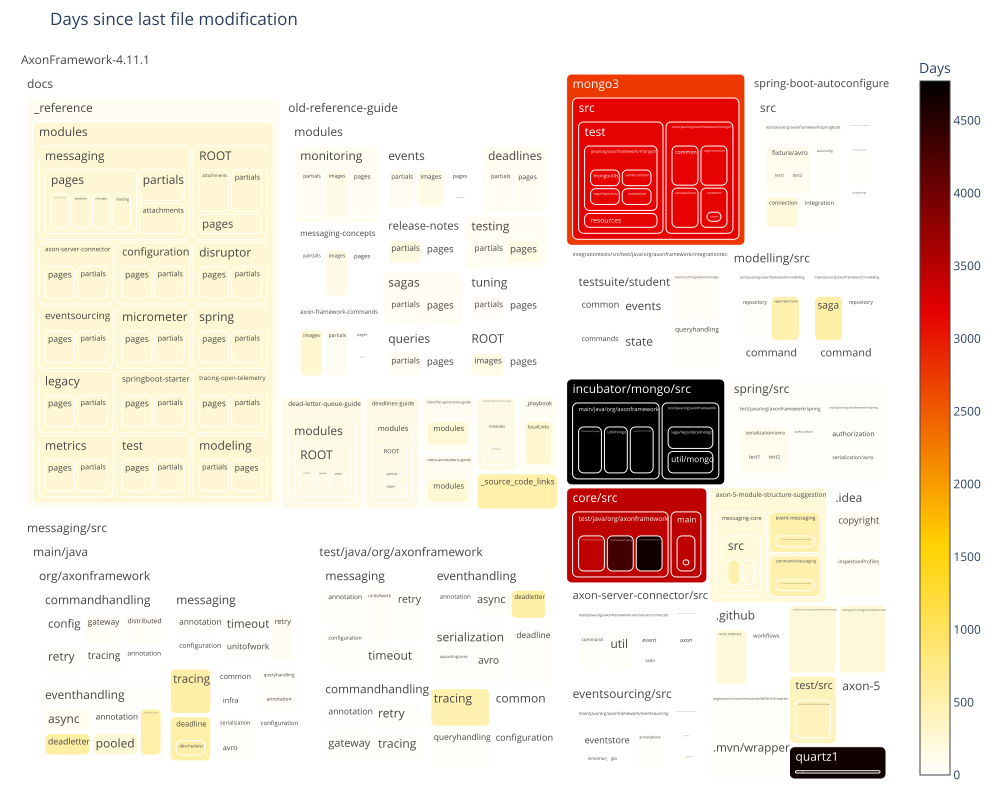

In [29]:
git_commit_days_since_last_file_modification_per_directory = add_quantile_limited_column(git_files_with_commit_statistics, "daysSinceLastModification", 0.98)

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_days_since_last_file_modification_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_commit_days_since_last_file_modification_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_days_since_last_file_modification_per_directory['daysSinceLastModification_limited'], 
        colorbar=dict(title="Days"),
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Days since last file modification',
)
figure.show(**plotly_treemap_figure_show_settings)

### Days since last file modification per directory (ranked)

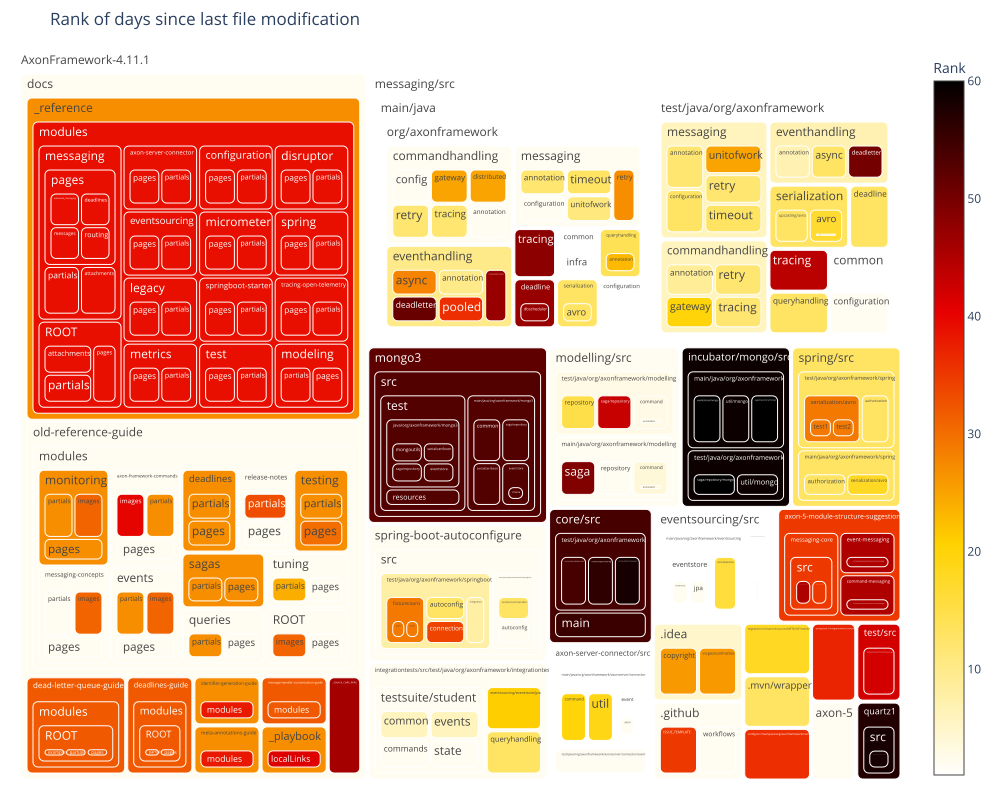

In [30]:
git_commit_days_since_last_file_modification_per_directory = add_rank_column(git_files_with_commit_statistics, "daysSinceLastModification")

figure = plotly_graph_objects.Figure(plotly_graph_objects.Treemap(
    create_treemap_commit_statistics_settings(git_commit_days_since_last_file_modification_per_directory),
    # Without values, much more squares are shown which gives a much better overview. The drawback is that the fileCount isn't visible.
    # values = git_commit_days_since_last_file_modification_per_directory['fileCount'],
    marker=dict(
        **plotly_treemap_marker_base_colorscale,
        colors=git_commit_days_since_last_file_modification_per_directory['daysSinceLastModification_rank'], 
        colorbar=dict(title="Rank"),
    ),
))
figure.update_layout(
    **plotly_treemap_layout_base_settings,
    title='Rank of days since last file modification',
)
figure.show(**plotly_treemap_figure_show_settings)

## Filecount per commit

Shows how many commits had changed one file, how many had changed two files, and so on.
The chart is limited to 30 lines for improved readability.
The data preview also includes overall statistics including the number of commits that are filtered out in the chart.

### Preview data

In [31]:
git_file_count_per_commit = query_cypher_to_data_frame("../cypher/GitLog/List_git_files_per_commit_distribution.cypher")

print("Sum of commits that changed more than 30 files (each) = " + str(git_file_count_per_commit[git_file_count_per_commit['filesPerCommit'] > 30]['commitCount'].sum()))
print("Max changed files with one commit = " + str(git_file_count_per_commit['filesPerCommit'].max()))
display(git_file_count_per_commit.describe())
display(git_file_count_per_commit.head(30))

Sum of commits that changed more than 30 files (each) = 1168
Max changed files with one commit = 4041


,filesPerCommit,commitCount
count,377.000000,377.000000
mean,398.572944,35.111406
std,559.546155,298.728099
min,1.000000,1.000000
25%,95.000000,1.000000
50%,204.000000,2.000000
75%,429.000000,5.000000
max,4041.000000,5197.000000


,filesPerCommit,commitCount
0,1,5197
1,2,2216
2,3,1033
3,4,648
4,5,435
5,6,327
6,7,261
7,8,214
8,9,160
9,10,145


### Bar chart with the number of files per commit distribution

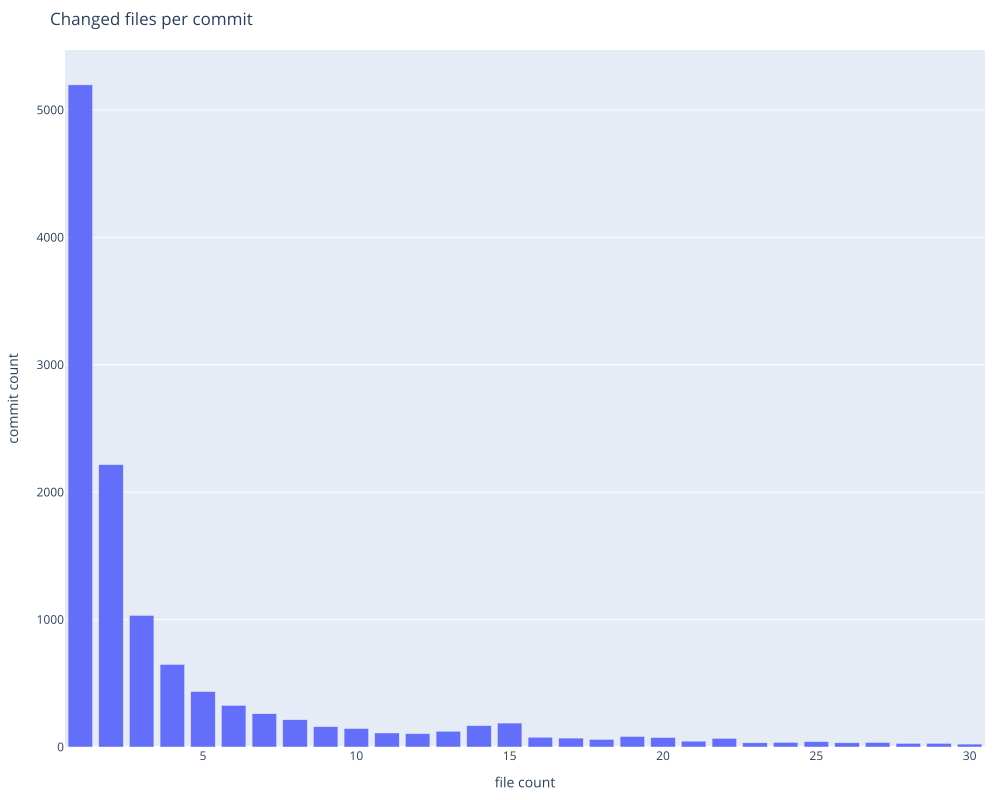

In [32]:
if git_file_count_per_commit.empty:
    print("No data to plot")
else:
    figure = plotly_graph_objects.Figure(plotly_graph_objects.Bar(
        x=git_file_count_per_commit['filesPerCommit'].head(30), 
        y=git_file_count_per_commit['commitCount'].head(30)),
    )
    figure.update_layout(
        **plotly_bar_layout_base_settings,
        title='Changed files per commit',
        xaxis_title='file count',
        yaxis_title='commit count'
    )
    figure.show(**plotly_treemap_figure_show_settings)

## WordCloud of git authors

In [33]:
# Query data from graph database
git_author_words_with_frequency = query_cypher_to_data_frame("../cypher/Overview/Words_for_git_author_Wordcloud_with_frequency.cypher")

git_author_words_with_frequency.sort_values(by='frequency', ascending=False).reset_index(drop=True).head(10)

,word,frequency
0,Steven van Beelen,4305
1,Allard Buijze,3148
2,smcvb,822
3,Milan Savic,449
4,Mateusz Nowak,412
5,Mitchell Herrijgers,408
6,Gerard Klijs,247
7,Marc Gathier,231
8,sara pellegrini,163
9,Rene de Waele,129


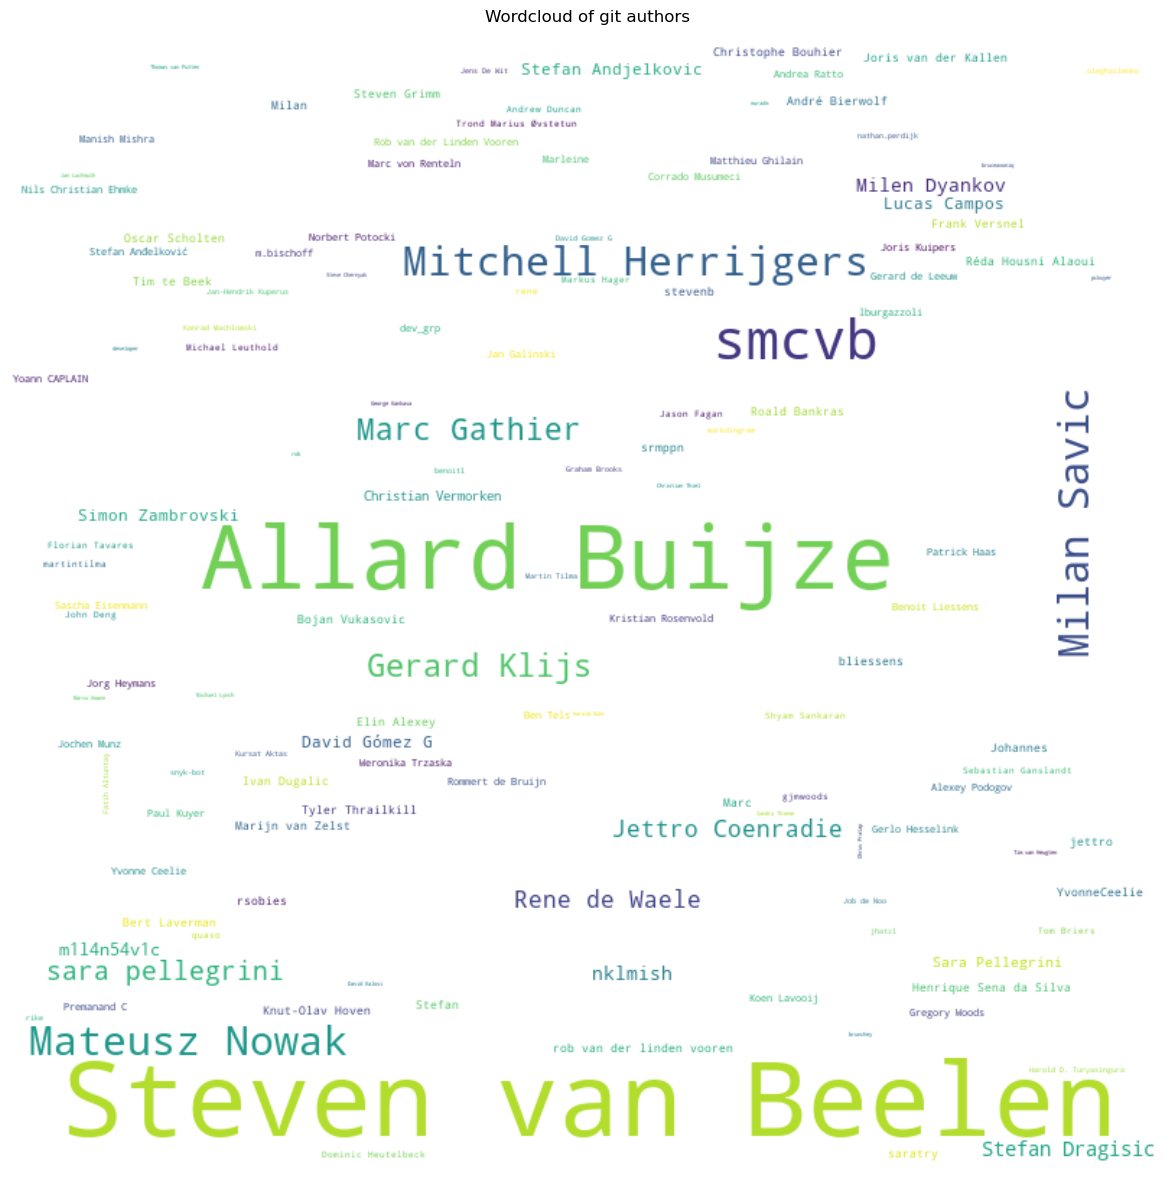

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plot

if not git_author_words_with_frequency.empty:
    # Expects the first column of the DataFrame to contain the words/text and the second column to contain the count/frequency.
    words_with_frequency_dict=git_author_words_with_frequency.set_index(git_author_words_with_frequency.columns[0]).to_dict()[git_author_words_with_frequency.columns[1]]
    wordcloud = WordCloud(
        width=800, 
        height=800,
        max_words=600, 
        collocations=False,
        background_color='white', 
        colormap='viridis'
    ).generate_from_frequencies(words_with_frequency_dict)

    # Plot the word cloud
    plot.figure(figsize=(15,15))
    plot.imshow(wordcloud, interpolation='bilinear')
    plot.axis("off")
    plot.title('Wordcloud of git authors')
    plot.show()